# Итоговое сравнение стратегий Pair Generator V0–V3.2

Этот ноутбук собирает финальный экспериментальный блок по стратегиям генерации A/B-пар для контура персонализации эквалайзера.

Цель: получить аккуратные таблицы и графики, которые можно использовать в статье или дипломе.

Сравниваются стратегии:

- `random` — V0 baseline;
- `uncertainty_axis` — V1 axis-based baseline;
- `semantic_control` — V2 semantic 4D;
- `semantic_control_v21` — V2.1 semantic 6D;
- `semantic_active_v21` — V3 active semantic selector;
- `candidate_pool_active` — V3.1 mixed candidate-pool active selector;
- `adaptive_router_v32` — V3.2 heuristic router.

Основной режим для интерпретации — `archetype8d`, так как он моделирует более реалистичных пользователей: архетипы, intensity, экстремальные предпочтения и индивидуальный шум.


## 1. Импорты и конфигурация

Графики сохраняются в светлой теме в `outputs/figures`, а таблицы — в `outputs/tables` и `outputs/metrics`.

Технические названия стратегий и режимов оставлены на английском языке, а подписи осей и заголовки — на русском. Так графики выглядят аккуратно для русскоязычной статьи, но сохраняют термины модели без перевода.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Ноутбук можно запускать как из research/notebooks, так и из корня research.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from personalization.article_results import (
    ARTICLE_STRATEGIES,
    STRATEGY_DESCRIPTIONS,
    ensure_article_dirs,
    run_article_batch,
    save_article_tables,
    make_target_mode_summary_table,
    make_winners_table,
    make_archetype_improvement_table,
    plot_mean_final_distance_by_target_mode,
    plot_mean_convergence,
    plot_final_distance_boxplot,
    plot_win_rates_vs_random,
    plot_intensity_analysis,
    plot_archetype_v3_improvement,
)

DATASET_PATH = PROJECT_ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
N_STEPS = 25
STEP_SCALE = 0.6
LR = 0.25
OUTPUT_PREFIX = "article_pair_generator"

OUTPUT_DIRS = ensure_article_dirs(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_PATH:", DATASET_PATH)
print("Figures dir:", OUTPUT_DIRS["figures"])
print("Tables dir:", OUTPUT_DIRS["tables"])


PROJECT_ROOT: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization
DATASET_PATH: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\datasets\synthetic_users_v21.csv
Figures dir: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures
Tables dir: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\tables


## 2. Набор synthetic users

В эксперименте используется фиксированный synthetic user dataset. Это важно для честного сравнения: все стратегии проходят одних и тех же пользователей с одинаковыми `z_target`, `feature_importance`, уровнем шума и метаданными.

Режимы генерации:

- `random8d` — стресс-тест: произвольные target-векторы во всём weighted 8D-пространстве;
- `semantic4d` — target лежит в исходном 4D semantic-подпространстве;
- `semantic6d` — target лежит в расширенном 6D semantic-подпространстве;
- `archetype8d` — реалистичные пользователи: архетипы, intensity и индивидуальный шум.


In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_PATH}. Сначала запусти notebooks/00_generate_synthetic_users_dataset.ipynb"
    )

dataset = pd.read_csv(DATASET_PATH)

print("Dataset shape:", dataset.shape)
display(dataset["target_mode"].value_counts().rename("users").to_frame())

preview_cols = [
    "user_id", "target_mode", "noise_std",
    "main_archetype", "intensity_label", "intensity_value",
]
preview_cols = [col for col in preview_cols if col in dataset.columns]
display(dataset[preview_cols].head(8))


Dataset shape: (400, 48)


,users
target_mode,
random8d,100
semantic4d,100
semantic6d,100
archetype8d,100


,user_id,target_mode,noise_std,main_archetype,intensity_label,intensity_value
0,0,random8d,0.05,none,random,1.0
1,1,random8d,0.05,none,random,1.0
2,2,random8d,0.05,none,random,1.0
3,3,random8d,0.05,none,random,1.0
4,4,random8d,0.05,none,random,1.0
5,5,random8d,0.05,none,random,1.0
6,6,random8d,0.05,none,random,1.0
7,7,random8d,0.05,none,random,1.0


## 3. Таблица стратегий

Эта таблица фиксирует экспериментальную линейку Pair Generator V0–V3.2. Её можно использовать как основу для раздела методики.


In [3]:
display(STRATEGY_DESCRIPTIONS)
STRATEGY_DESCRIPTIONS.to_csv(OUTPUT_DIRS["tables"] / "article_strategy_descriptions.csv", index=False)


,version,strategy,display_name,short_description,role
0,V0,random,Random direction,Случайное многомерное направление в weighted 8D.,"Базовый baseline для проверки, лучше ли новая ..."
1,V1,uncertainty_axis,Uncertainty axis,"A/B-вопрос по одной 8D-оси, выбранной по текущ...",Интерпретируемый baseline: уточнение конкретно...
2,V2,semantic_control,Semantic 4D,"4D semantic basis: low_power, warmth_body, pre...",Проверка гипотезы о полезности музыкально осмы...
3,V2.1,semantic_control_v21,Semantic 6D v2.1,6D semantic basis: V2 + club_energy + clean_bass.,Расширенная semantic basis для club/bass-orien...
4,V3,semantic_active_v21,Semantic active v3,Активный выбор semantic-вопроса по question-us...,Основной кандидат Pair Generator для реалистич...
5,V3.1,candidate_pool_active,Candidate pool active,Смешанный пул random / axis / semantic кандида...,Более универсальный mixed-exploration baseline.
6,V3.2,adaptive_router_v32,Adaptive router v3.2,"Эвристический router между semantic-active, ca...",Экспериментальная попытка адаптивного переключ...


## 4. Запуск batch-эксперимента

На каждом synthetic user каждая стратегия проходит одинаковое число A/B-шагов. Метрика `final_distance` — евклидово расстояние между финальным `preference state` и скрытым `z_target` в weighted 8D-пространстве. Это не MSE по EQ-кривой, а ошибка персонализации в compact-пространстве.


In [4]:
sessions, curves, strategy_summary, win_rates, sessions_with_meta = run_article_batch(
    dataset=dataset,
    strategies=ARTICLE_STRATEGIES,
    n_steps=N_STEPS,
    step_scale=STEP_SCALE,
    lr=LR,
)

# Сохраняем сырые результаты и агрегаты.
sessions.to_csv(OUTPUT_DIRS["metrics"] / f"{OUTPUT_PREFIX}_sessions.csv", index=False)
sessions_with_meta.to_csv(OUTPUT_DIRS["metrics"] / f"{OUTPUT_PREFIX}_sessions_with_meta.csv", index=False)
strategy_summary.to_csv(OUTPUT_DIRS["metrics"] / f"{OUTPUT_PREFIX}_strategy_summary.csv", index=False)
win_rates.to_csv(OUTPUT_DIRS["metrics"] / f"{OUTPUT_PREFIX}_win_rates.csv", index=False)

print("sessions:", sessions.shape)
print("strategy_summary:", strategy_summary.shape)
print("win_rates:", win_rates.shape)


sessions: (2800, 10)
strategy_summary: (28, 10)
win_rates: (24, 5)


## 5. Сводные таблицы

Ниже формируются основные таблицы для статьи:

1. средние метрики по `target_mode` и стратегии;
2. победитель в каждом режиме target;
3. win-rate стратегий относительно `random`;
4. улучшение V3 `semantic_active_v21` относительно V2.1 `semantic_control_v21` по архетипам.


In [5]:
target_mode_summary_table = make_target_mode_summary_table(strategy_summary)
winners_table = make_winners_table(strategy_summary)
archetype_improvement_table = make_archetype_improvement_table(sessions_with_meta)

table_paths = save_article_tables(
    strategy_summary=strategy_summary,
    win_rates=win_rates,
    sessions_with_meta=sessions_with_meta,
    output_dir=OUTPUT_DIRS["tables"],
)

print("Saved article tables:")
for name, path in table_paths.items():
    print(f"  {name}: {path}")

display(Markdown("### Победители по режимам генерации target"))
display(winners_table.round(4))

display(Markdown("### Сводка по target_mode и strategy"))
display(target_mode_summary_table.round(4))

display(Markdown("### V3 vs V2.1 по архетипам"))
display(archetype_improvement_table.round(4))


Saved article tables:
  strategy_descriptions: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\tables\article_strategy_descriptions.csv
  target_mode_summary: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\tables\article_target_mode_summary.csv
  target_mode_winners: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\tables\article_target_mode_winners.csv
  win_rates_vs_random: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\tables\article_win_rates_vs_random.csv
  v3_vs_v21_by_archetype: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\tables\article_v3_vs_v21_by_archetype.csv


### Победители по режимам генерации target

,target_mode,winner,mean_final_distance,mean_best_distance,mean_improvement_pct
0,Archetype 8D,Semantic active v3,0.3789,0.2806,57.6778
1,Random 8D,Uncertainty axis,0.9858,0.9607,56.6639
2,Semantic 4D,Adaptive router v3.2,0.4036,0.3151,74.8371
3,Semantic 6D,Adaptive router v3.2,0.5455,0.4986,75.8121


### Сводка по target_mode и strategy

,target_mode,strategy,users,mean_final_distance,std_final_distance,mean_best_distance,mean_improvement_pct
3,Archetype 8D,Semantic active v3,100,0.3789,0.1335,0.2806,57.6778
0,Archetype 8D,Adaptive router v3.2,100,0.3996,0.1318,0.2813,54.3446
5,Archetype 8D,Semantic 6D v2.1,100,0.4770,0.1648,0.3222,44.7058
1,Archetype 8D,Candidate pool active,100,0.4867,0.1725,0.3487,43.7057
4,Archetype 8D,Semantic 4D,100,0.5145,0.2407,0.3707,41.2258
6,Archetype 8D,Uncertainty axis,100,0.5337,0.2591,0.4439,41.0218
2,Archetype 8D,Random direction,100,0.5678,0.2146,0.4728,35.8415
13,Random 8D,Uncertainty axis,100,0.9858,0.4159,0.9607,56.6639
8,Random 8D,Candidate pool active,100,0.9926,0.4261,0.9760,56.2543
9,Random 8D,Random direction,100,0.9967,0.4021,0.9790,55.8002


### V3 vs V2.1 по архетипам

strategy,archetype,semantic_active_v3_final_distance,semantic_6d_v21_final_distance,users,improvement_abs,improvement_pct,winner
0,bass_lover,0.3329,0.5181,7,0.1851,35.7341,Semantic active v3
6,mid_forward,0.3942,0.5726,7,0.1784,31.1539,Semantic active v3
7,neutral,0.2971,0.4181,15,0.1210,28.9326,Semantic active v3
11,warm,0.3230,0.4298,14,0.1068,24.8457,Semantic active v3
1,basshead,0.4556,0.5694,11,0.1138,19.9799,Semantic active v3
4,detail_focused,0.3376,0.4070,10,0.0694,17.0439,Semantic active v3
8,soft_dark,0.3871,0.4648,9,0.0777,16.7246,Semantic active v3
5,extreme_vshape,0.5498,0.6446,6,0.0948,14.7067,Semantic active v3
3,club_curve,0.4196,0.4724,11,0.0528,11.1702,Semantic active v3
10,v_shape,0.4246,0.4612,5,0.0366,7.9413,Semantic active v3


## 6. График 1 — среднее финальное расстояние по target mode

Этот график показывает, какая стратегия лучше сходится в разных режимах генерации пользователей. Для `random8d` ожидаемо сильны более общие стратегии, а для `semantic`/`archetype` режимов должны выигрывать semantic-based подходы.


,Random direction,Uncertainty axis,Semantic 4D,Semantic 6D v2.1,Semantic active v3,Candidate pool active,Adaptive router v3.2
Random 8D,0.9967,0.9858,1.5689,1.5858,1.5091,0.9926,1.5089
Semantic 4D,0.7363,0.6896,0.4978,0.5715,0.4100,0.5716,0.4036
Semantic 6D,1.0877,1.0084,0.7163,0.6524,0.5516,0.8631,0.5455
Archetype 8D,0.5678,0.5337,0.5145,0.4770,0.3789,0.4867,0.3996


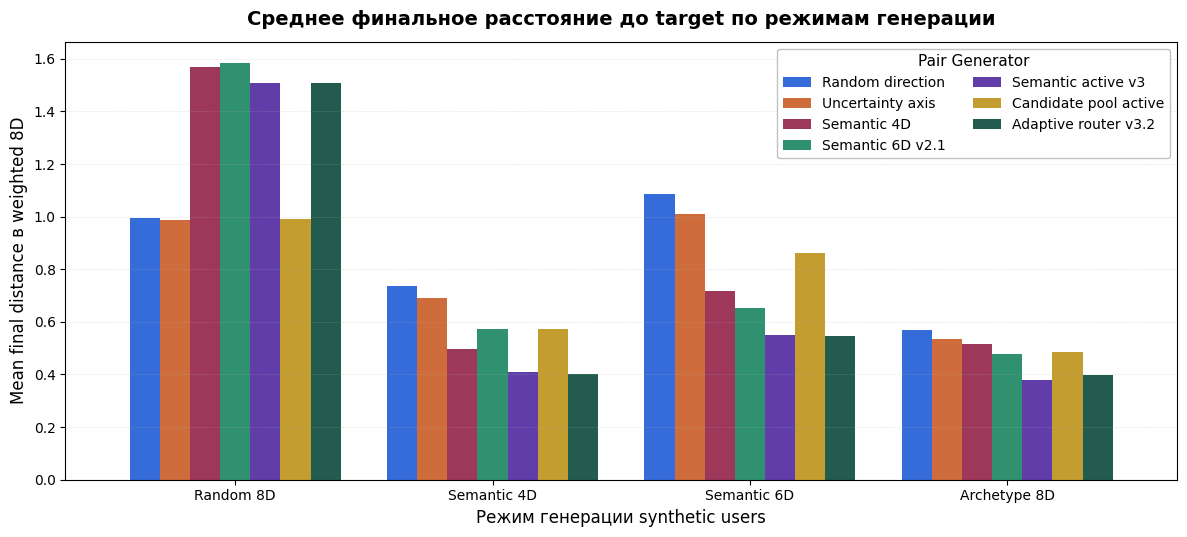

In [6]:
fig, ax, final_distance_table = plot_mean_final_distance_by_target_mode(
    strategy_summary,
    save_path=OUTPUT_DIRS["figures"] / f"{OUTPUT_PREFIX}_mean_final_distance_by_target_mode.png",
)

display(final_distance_table.round(4))


## 7. График 2 — средняя сходимость на реалистичных пользователях

`archetype8d` — основной режим для интерпретации, потому что он ближе к реальному поведению пользователей: архетипы, выраженность предпочтений и индивидуальный шум.


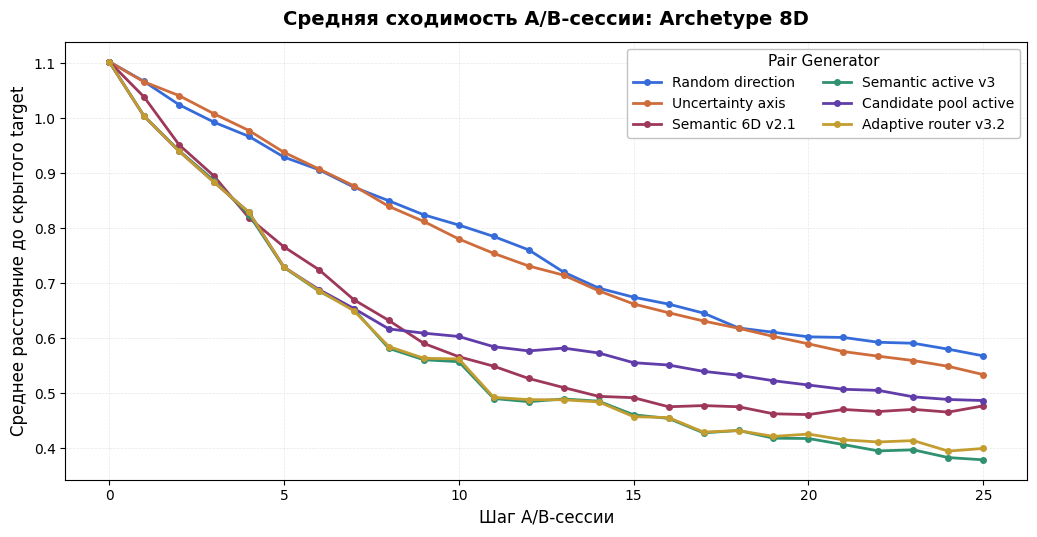

In [7]:
fig, ax = plot_mean_convergence(
    curves,
    target_mode="archetype8d",
    save_path=OUTPUT_DIRS["figures"] / f"{OUTPUT_PREFIX}_convergence_archetype8d.png",
)


## 8. График 3 — распределение final distance на Archetype 8D

Boxplot полезен для статьи, потому что показывает не только среднее значение, но и разброс качества по synthetic users.


## 9. График 4 — win-rate относительно random baseline

Win-rate показывает, в каком проценте пользовательских сессий стратегия дала меньший `final_distance`, чем `random`. Значение выше 50% означает, что стратегия чаще выигрывает у baseline.


,label,target_mode,strategy,baseline,win_rate_final_distance,win_rate_best_distance
0,Uncertainty axis,archetype8d,uncertainty_axis,random,0.61,0.58
1,Semantic 6D v2.1,archetype8d,semantic_control_v21,random,0.65,0.79
2,Semantic active v3,archetype8d,semantic_active_v21,random,0.88,0.94
3,Candidate pool active,archetype8d,candidate_pool_active,random,0.63,0.82
4,Adaptive router v3.2,archetype8d,adaptive_router_v32,random,0.84,0.93


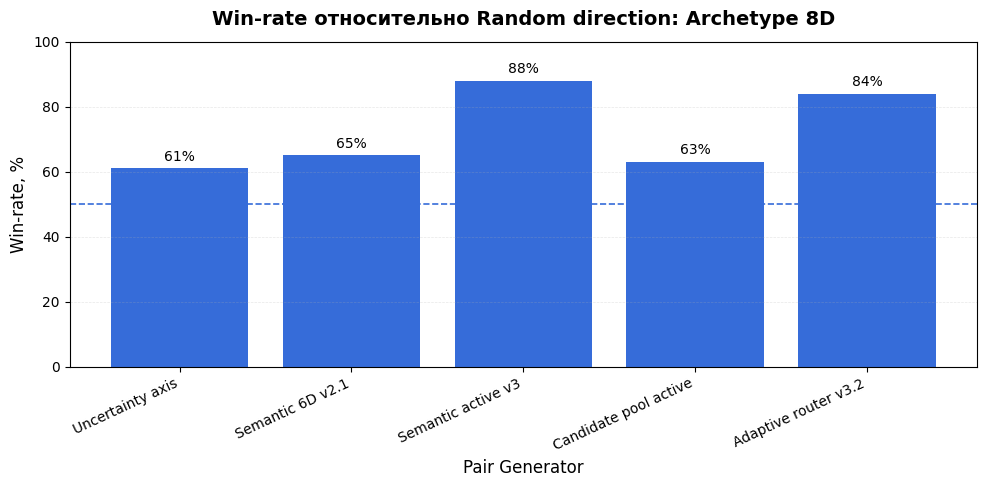

In [9]:
fig, ax, archetype_winrate_table = plot_win_rates_vs_random(
    win_rates,
    target_mode="archetype8d",
    save_path=OUTPUT_DIRS["figures"] / f"{OUTPUT_PREFIX}_win_rate_archetype8d.png",
)

display(archetype_winrate_table.round(4))


## 10. График 5 — анализ по intensity

Этот график показывает, сохраняется ли преимущество стратегии на пользователях с разной выраженностью предпочтений: `mild`, `moderate`, `strong`, `extreme`. Для проекта особенно важны `strong` и `extreme`, потому что часть реальных пользователей может любить выраженные басовые или V-shape калибровки.


,Random direction,Semantic 6D v2.1,Semantic active v3,Candidate pool active,Adaptive router v3.2
intensity_label,,,,,
mild,0.4440,0.4265,0.3243,0.4409,0.3543
moderate,0.5500,0.4566,0.3533,0.4462,0.3822
strong,0.6261,0.4935,0.4003,0.5008,0.4068
extreme,0.6274,0.5477,0.4587,0.6083,0.4741


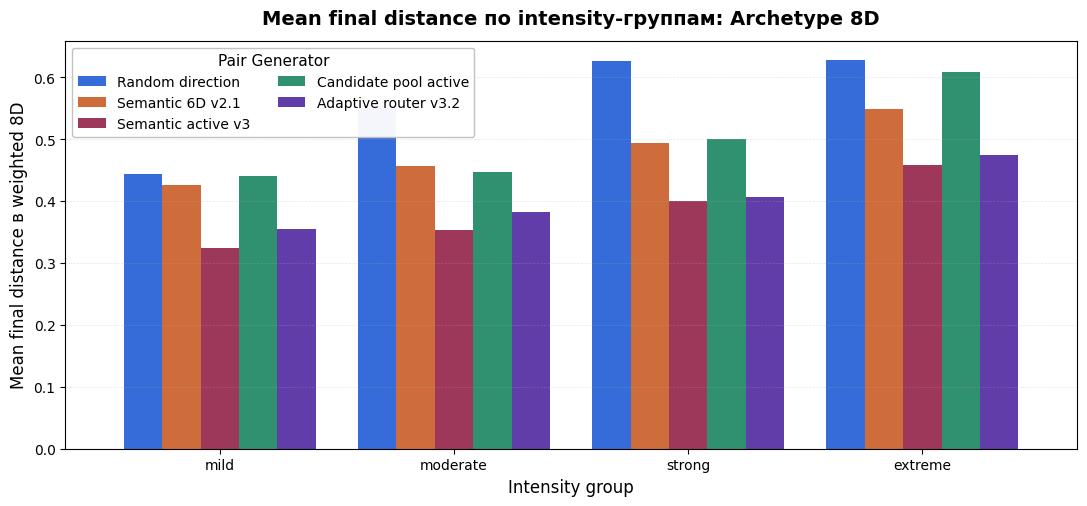

In [10]:
fig, ax, intensity_table = plot_intensity_analysis(
    sessions_with_meta,
    save_path=OUTPUT_DIRS["figures"] / f"{OUTPUT_PREFIX}_intensity_archetype8d.png",
)

display(intensity_table.round(4))


## 11. График 6 — улучшение V3 относительно V2.1 по архетипам

Этот график показывает, насколько активный выбор semantic-вопроса (`semantic_active_v21`) улучшил простую semantic-стратегию V2.1 (`semantic_control_v21`) для разных пользовательских архетипов.


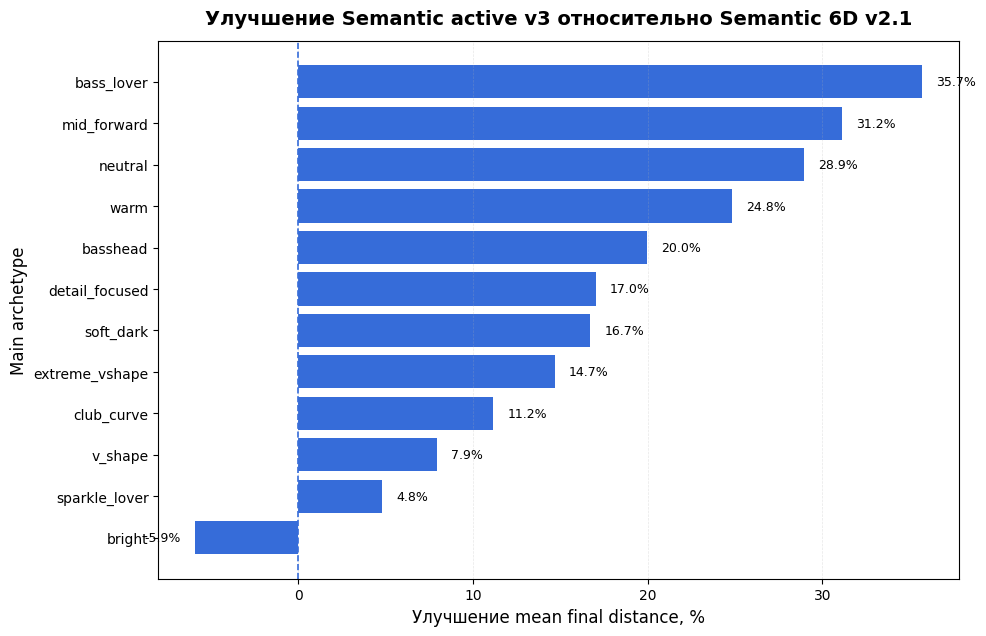

In [11]:
fig, ax = plot_archetype_v3_improvement(
    archetype_improvement_table,
    save_path=OUTPUT_DIRS["figures"] / f"{OUTPUT_PREFIX}_v3_vs_v21_by_archetype.png",
)


## 12. Автоматический текстовый вывод

Эта ячейка формирует короткий вывод на основе фактических результатов текущего запуска. Его можно использовать как основу для раздела статьи.


In [12]:
def get_metric(summary, target_mode, strategy, column):
    row = summary[(summary["target_mode"] == target_mode) & (summary["strategy"] == strategy)]
    if row.empty:
        return np.nan
    return float(row.iloc[0][column])

def get_win_rate(win_rates_df, target_mode, strategy, column="win_rate_final_distance"):
    row = win_rates_df[(win_rates_df["target_mode"] == target_mode) & (win_rates_df["strategy"] == strategy)]
    if row.empty:
        return np.nan
    return float(row.iloc[0][column])

archetype_v3_final = get_metric(strategy_summary, "archetype8d", "semantic_active_v21", "mean_final_distance")
archetype_random_final = get_metric(strategy_summary, "archetype8d", "random", "mean_final_distance")
archetype_v21_final = get_metric(strategy_summary, "archetype8d", "semantic_control_v21", "mean_final_distance")
archetype_candidate_final = get_metric(strategy_summary, "archetype8d", "candidate_pool_active", "mean_final_distance")
archetype_router_final = get_metric(strategy_summary, "archetype8d", "adaptive_router_v32", "mean_final_distance")

win_v3_final = get_win_rate(win_rates, "archetype8d", "semantic_active_v21", "win_rate_final_distance")
win_v3_best = get_win_rate(win_rates, "archetype8d", "semantic_active_v21", "win_rate_best_distance")

random8d_best = winners_table.loc[winners_table["target_mode"] == "Random 8D", "winner"].iloc[0]
semantic4d_best = winners_table.loc[winners_table["target_mode"] == "Semantic 4D", "winner"].iloc[0]
semantic6d_best = winners_table.loc[winners_table["target_mode"] == "Semantic 6D", "winner"].iloc[0]
archetype8d_best = winners_table.loc[winners_table["target_mode"] == "Archetype 8D", "winner"].iloc[0]

text = f"""
### Итоговый вывод по блоку Pair Generator

В эксперименте была проверена линейка стратегий Pair Generator от простого `random` baseline до активных стратегий V3–V3.2. Результаты показывают, что эффективность стратегии зависит от структуры скрытого target-вектора пользователя.

В режиме `Random 8D`, где target произволен во всём weighted 8D-пространстве, лучшей стратегией стала `{random8d_best}`. Это ожидаемо: semantic-подходи ограничивают пространство поиска и не обязаны покрывать произвольный 8D-target.

В структурированных режимах картина другая: для `Semantic 4D` победила `{semantic4d_best}`, для `Semantic 6D` — `{semantic6d_best}`, а для наиболее реалистичного режима `Archetype 8D` — `{archetype8d_best}`.

На `Archetype 8D` стратегия `Semantic active v3` достигла mean final distance `{archetype_v3_final:.3f}`. Для сравнения, `Random direction` получил `{archetype_random_final:.3f}`, `Semantic 6D v2.1` — `{archetype_v21_final:.3f}`, `Candidate pool active` — `{archetype_candidate_final:.3f}`, а `Adaptive router v3.2` — `{archetype_router_final:.3f}`.

Win-rate `Semantic active v3` относительно `Random direction` на `Archetype 8D` составил `{win_v3_final * 100:.1f}%` по final distance и `{win_v3_best * 100:.1f}%` по best distance. Это означает, что активный semantic Pair Generator выигрывает у случайного baseline в большинстве реалистичных synthetic-сессий.

Таким образом, `Semantic active v3` можно зафиксировать как основную стратегию Pair Generator для текущей версии контура персонализации. `Candidate pool active` и `Adaptive router v3.2` полезны как дополнительные эксперименты и универсальные baseline, но в текущей реализации не превосходят `Semantic active v3` на реалистичных `Archetype 8D` пользователях.
"""

display(Markdown(text))



### Итоговый вывод по блоку Pair Generator

В эксперименте была проверена линейка стратегий Pair Generator от простого `random` baseline до активных стратегий V3–V3.2. Результаты показывают, что эффективность стратегии зависит от структуры скрытого target-вектора пользователя.

В режиме `Random 8D`, где target произволен во всём weighted 8D-пространстве, лучшей стратегией стала `Uncertainty axis`. Это ожидаемо: semantic-подходи ограничивают пространство поиска и не обязаны покрывать произвольный 8D-target.

В структурированных режимах картина другая: для `Semantic 4D` победила `Adaptive router v3.2`, для `Semantic 6D` — `Adaptive router v3.2`, а для наиболее реалистичного режима `Archetype 8D` — `Semantic active v3`.

На `Archetype 8D` стратегия `Semantic active v3` достигла mean final distance `0.379`. Для сравнения, `Random direction` получил `0.568`, `Semantic 6D v2.1` — `0.477`, `Candidate pool active` — `0.487`, а `Adaptive router v3.2` — `0.400`.

Win-rate `Semantic active v3` относительно `Random direction` на `Archetype 8D` составил `88.0%` по final distance и `94.0%` по best distance. Это означает, что активный semantic Pair Generator выигрывает у случайного baseline в большинстве реалистичных synthetic-сессий.

Таким образом, `Semantic active v3` можно зафиксировать как основную стратегию Pair Generator для текущей версии контура персонализации. `Candidate pool active` и `Adaptive router v3.2` полезны как дополнительные эксперименты и универсальные baseline, но в текущей реализации не превосходят `Semantic active v3` на реалистичных `Archetype 8D` пользователях.


## 13. Краткий вывод для статьи

```text
Эксперименты показали, что стратегия генерации A/B-пар должна учитывать структуру пространства пользовательских предпочтений. Случайные и осевые стратегии остаются полезными baseline для произвольного 8D-пространства, однако на реалистичных пользователях, сгенерированных через архетипы и intensity, лучшим вариантом стала стратегия Semantic active v3. Она использует расширенную semantic basis v2.1 и выбирает следующий A/B-вопрос по question-usefulness score, учитывающему неопределённость, различимость пары, safety и повторяемость вопросов. По сравнению с random baseline Semantic active v3 снижает среднее финальное расстояние до скрытого target и чаще выигрывает по final/best distance, поэтому она выбрана как основной Pair Generator для дальнейшего развития personalization loop.
```


## 14. Сохранённые артефакты

После выполнения ноутбука основные файлы будут сохранены в:

- `outputs/figures/article_pair_generator_*.png` — графики для статьи;
- `outputs/tables/article_*.csv` — итоговые таблицы;
- `outputs/metrics/article_pair_generator_*.csv` — сырые результаты и агрегированные метрики.
